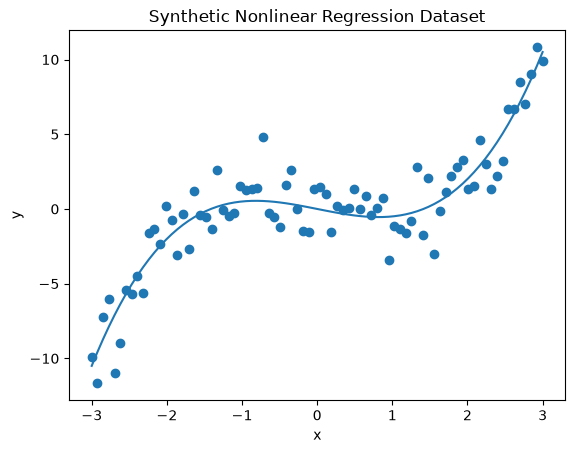

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

X = np.linspace(-3, 3, 80).reshape(-1, 1)

y_true = 0.5 * X[:, 0]**3 - X[:, 0]
noise = rng.normal(0, 2.0, size=len(X))

y = y_true + noise

plt.scatter(X[:, 0], y)
plt.plot(X[:, 0], y_true)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Synthetic Nonlinear Regression Dataset")
plt.show()

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

X_train, X_val, y_train, y_val = train_test_split(X, y,test_size=0.25,random_state=42)

linear = LinearRegression()
linear.fit(X_train, y_train)

train_pred = linear.predict(X_train)
val_pred = linear.predict(X_val)

train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))

print("Train RMSE:", train_rmse)
print("Validation RMSE:", val_rmse)

Train RMSE: 2.5483216125002435
Validation RMSE: 3.2602762323945966


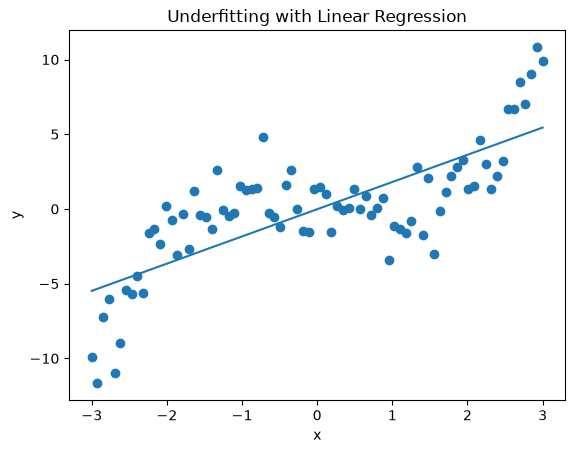

In [3]:
x_plot = np.linspace(-3, 3, 300).reshape(-1, 1)
y_plot = linear.predict(x_plot)

plt.scatter(X[:, 0], y)
plt.plot(x_plot[:, 0], y_plot)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Underfitting with Linear Regression")
plt.show()

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

flexible_model = Pipeline([
    ("poly", PolynomialFeatures(degree=15, include_bias=False)),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

flexible_model.fit(X_train, y_train)

train_pred = flexible_model.predict(X_train)
val_pred = flexible_model.predict(X_val)

train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))

print("Train RMSE:", train_rmse)
print("Validation RMSE:", val_rmse)

Train RMSE: 1.1892220207049404
Validation RMSE: 4.017088854586884


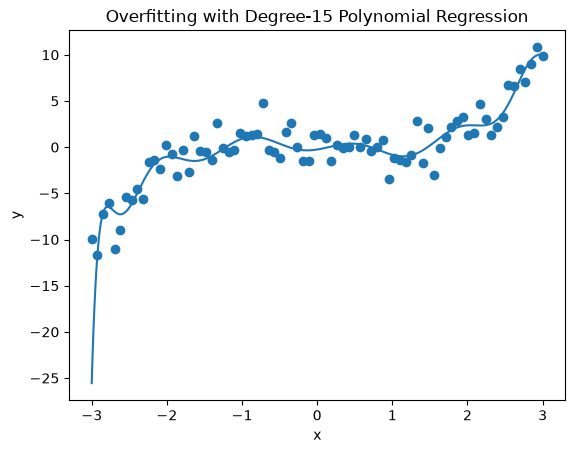

In [5]:
x_plot = np.linspace(-3, 3, 500).reshape(-1, 1)
y_plot = flexible_model.predict(x_plot)

plt.scatter(X[:, 0], y)
plt.plot(x_plot[:, 0], y_plot)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Overfitting with Degree-15 Polynomial Regression")
plt.show()

In [6]:
import pandas as pd
from pathlib import Path

ROOT = Path.cwd().parents[1]

df = pd.read_csv(ROOT / "data" / "duolingo_flagship_v5.csv")
split_df = pd.read_csv(ROOT / "data" / "split_users.csv")

cv_users = set(split_df.loc[split_df["split"] == "cv", "user_id"])

df_cv = df[df["user_id"].isin(cv_users)].copy()

features = [
    "lag_days",
    "history_seen",
    "history_correct",
    "history_accuracy",
    "lag_days_log"
]

X = df_cv[features]
y = df_cv["p_recall"]
groups = df_cv["user_id"]

print(X.shape)
print(groups.nunique())

(14438, 5)
2125


In [8]:
from sklearn.model_selection import GroupKFold

train_fractions = [0.2, 0.4, 0.6, 0.8, 1.0]

gkf = GroupKFold(n_splits=5)

for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups),start=1):
    train_users = groups.iloc[train_idx].unique()

    print(
        f"Fold {fold}: "
        f"{len(train_users)} train users, "
        f"{groups.iloc[val_idx].nunique()} validation users"
    )

Fold 1: 1700 train users, 425 validation users
Fold 2: 1700 train users, 425 validation users
Fold 3: 1700 train users, 425 validation users
Fold 4: 1700 train users, 425 validation users
Fold 5: 1700 train users, 425 validation users


In [9]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

train_rmses = {fraction: [] for fraction in train_fractions}
val_rmses = {fraction: [] for fraction in train_fractions}

gkf = GroupKFold(n_splits=5)

for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups),start=1):
    fold_train_users = groups.iloc[train_idx].unique()

    rng = np.random.default_rng(42 + fold)
    shuffled_users = rng.permutation(fold_train_users)

    X_val = X.iloc[val_idx]
    y_val = y.iloc[val_idx]

    for fraction in train_fractions:
        n_users = int(len(shuffled_users) * fraction)
        selected_users = set(shuffled_users[:n_users])

        subset_mask = groups.iloc[train_idx].isin(selected_users)

        subset_idx = train_idx[subset_mask]

        X_train_sub = X.iloc[subset_idx]
        y_train_sub = y.iloc[subset_idx]

        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("model", LinearRegression())
        ])

        pipeline.fit(X_train_sub, y_train_sub)

        train_pred = pipeline.predict(X_train_sub)
        val_pred = pipeline.predict(X_val)

        train_rmse = np.sqrt(mean_squared_error(y_train_sub, train_pred))
        val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))

        train_rmses[fraction].append(train_rmse)
        val_rmses[fraction].append(val_rmse)

In [10]:
for fraction in train_fractions:
    print(
        f"{fraction:.0%} users | "
        f"Train RMSE: {np.mean(train_rmses[fraction]):.6f} | "
        f"Val RMSE: {np.mean(val_rmses[fraction]):.6f}"
    )

20% users | Train RMSE: 0.266588 | Val RMSE: 0.275145
40% users | Train RMSE: 0.276684 | Val RMSE: 0.276543
60% users | Train RMSE: 0.273833 | Val RMSE: 0.274822
80% users | Train RMSE: 0.273521 | Val RMSE: 0.274214
100% users | Train RMSE: 0.273330 | Val RMSE: 0.273699


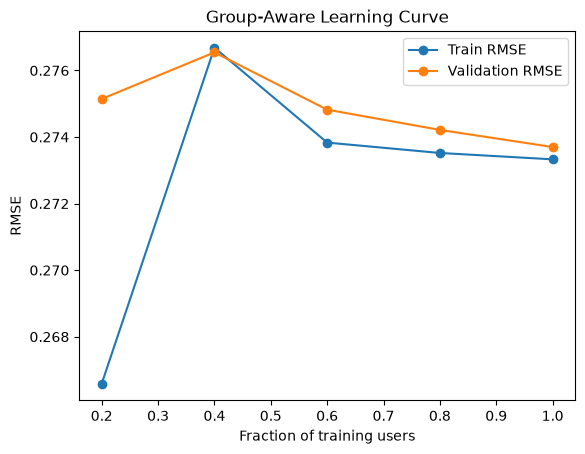

In [11]:
train_mean = [np.mean(train_rmses[f]) for f in train_fractions]
val_mean = [np.mean(val_rmses[f]) for f in train_fractions]

plt.plot(train_fractions, train_mean, marker="o", label="Train RMSE")
plt.plot(train_fractions, val_mean, marker="o", label="Validation RMSE")

plt.xlabel("Fraction of training users")
plt.ylabel("RMSE")
plt.title("Group-Aware Learning Curve")
plt.legend()
plt.show()

## Part 11 Conclusion

The synthetic experiments demonstrated both sides of the bias-variance tradeoff.

A simple linear model underfit a nonlinear relationship:

- Train RMSE: `2.55`
- Validation RMSE: `3.26`

Both errors were relatively high, indicating high bias.

A degree-15 polynomial model strongly reduced training error:

- Train RMSE: `1.19`
- Validation RMSE: `4.02`

The large train-validation gap indicated high variance and overfitting.

### Flagship Learning Curve

The group-aware learning curve used progressively larger subsets of training users while keeping validation users completely unseen.

At the full training size:

- Train RMSE: `0.273330`
- Validation RMSE: `0.273699`

The train-validation gap is extremely small, so the current linear model does not show a strong high-variance problem.

Validation performance also changes only slightly as more training users are added. This suggests that simply collecting more data of the same type is unlikely to produce a large improvement.

The current limitation appears to be closer to a bias / representation problem:

- the linear model may be too simple
- the current features may not capture enough structure
- nonlinear relationships may remain unexplained

Therefore, increasing model and feature capacity is a more promising next step than only adding more data.

This provides an empirical motivation for moving to tree-based and ensemble models in Month 3.